In [1]:
!pip install timm
!pip install kaggle

In [6]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [7]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:35<00:00, 158MB/s] 



In [9]:
import zipfile

with zipfile.ZipFile("skin-cancer-mnist-ham10000.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [10]:
import os

os.listdir("dataset")

['hmnist_8_8_RGB.csv',
 'HAM10000_images_part_2',
 'HAM10000_metadata.csv',
 'ham10000_images_part_2',
 'hmnist_8_8_L.csv',
 'hmnist_28_28_L.csv',
 'HAM10000_images_part_1',
 'hmnist_28_28_RGB.csv',
 'ham10000_images_part_1']

In [11]:
!pip install timm

In [12]:
!pip install timm

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import timm

In [14]:
df = pd.read_csv("dataset/HAM10000_metadata.csv")

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [15]:
label_mapping = {
    'nv':0,
    'mel':1,
    'bkl':2,
    'bcc':3,
    'akiec':4,
    'vasc':5,
    'df':6
}

df['label'] = df['dx'].map(label_mapping)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2


In [16]:
image_dir1 = "dataset/HAM10000_images_part_1"
image_dir2 = "dataset/HAM10000_images_part_2"

image_paths = []

for img_id in df['image_id']:

    path1 = os.path.join(image_dir1, img_id + ".jpg")
    path2 = os.path.join(image_dir2, img_id + ".jpg")

    if os.path.exists(path1):
        image_paths.append(path1)
    else:
        image_paths.append(path2)

df['path'] = image_paths

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,label,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2,dataset/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2,dataset/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2,dataset/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2,dataset/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2,dataset/HAM10000_images_part_2/ISIC_0031633.jpg


In [17]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 7010
Validation: 1502
Test: 1503


In [19]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [20]:
class SkinDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_path = self.dataframe.iloc[idx]['path']
        label = self.dataframe.iloc[idx]['label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [21]:
train_dataset = SkinDataset(train_df, transform)
val_dataset = SkinDataset(val_df, transform)
test_dataset = SkinDataset(test_df, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    'seresnet50',
    pretrained=True,
    num_classes=7
)

model = model.to(device)

print("SENet Model Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

SENet Model Loaded Successfully


In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [24]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 10

In [25]:
for epoch in range(epochs):

    # TRAINING MODE
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    # VALIDATION MODE
    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}]")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_accuracy:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Validation Accuracy: {val_accuracy:.4f}")

    print("-----------------------------------")

Epoch [1/10]
Train Loss: 0.7678
Train Accuracy: 0.7287
Validation Loss: 0.9579
Validation Accuracy: 0.7297
-----------------------------------
Epoch [2/10]
Train Loss: 0.5705
Train Accuracy: 0.7944
Validation Loss: 0.6395
Validation Accuracy: 0.7663
-----------------------------------
Epoch [3/10]
Train Loss: 0.4391
Train Accuracy: 0.8404
Validation Loss: 0.5825
Validation Accuracy: 0.7943
-----------------------------------
Epoch [4/10]
Train Loss: 0.3213
Train Accuracy: 0.8805
Validation Loss: 1.1470
Validation Accuracy: 0.7370
-----------------------------------
Epoch [5/10]
Train Loss: 0.2390
Train Accuracy: 0.9136
Validation Loss: 0.9973
Validation Accuracy: 0.7710
-----------------------------------
Epoch [6/10]
Train Loss: 0.1905
Train Accuracy: 0.9318
Validation Loss: 0.6267
Validation Accuracy: 0.7630
-----------------------------------
Epoch [7/10]
Train Loss: 0.1692
Train Accuracy: 0.9582
Validation Loss: 0.6709
Validation Accuracy: 0.7889
-----------------------------------

In [26]:
torch.save(model.state_dict(), "senet_skin_model.pth")

print("Model Saved Successfully")

Model Saved Successfully


In [27]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())

        all_preds.extend(predicted.cpu().numpy())

In [28]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

Accuracy : 0.7837658017298735
Precision: 0.7882430574947684
Recall   : 0.7837658017298735
F1 Score : 0.7503130140931131


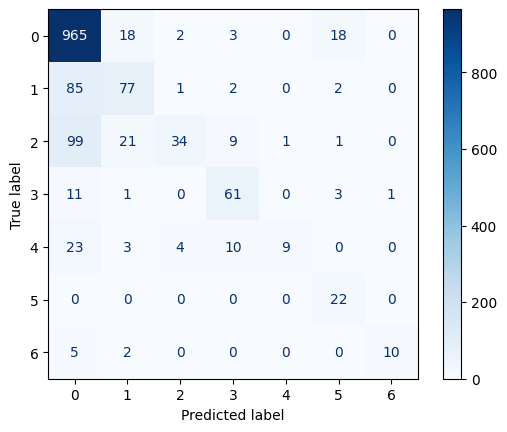

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.show()

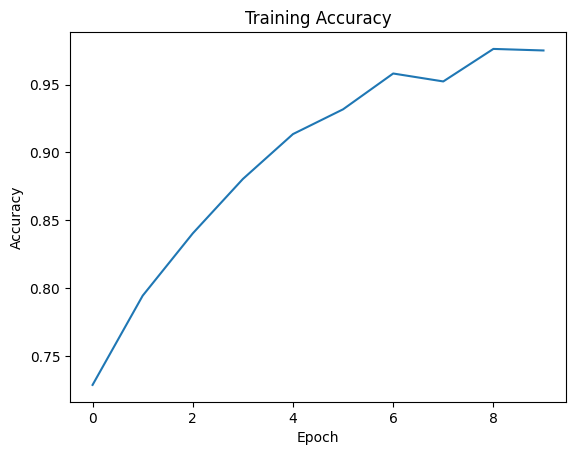

In [30]:
plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

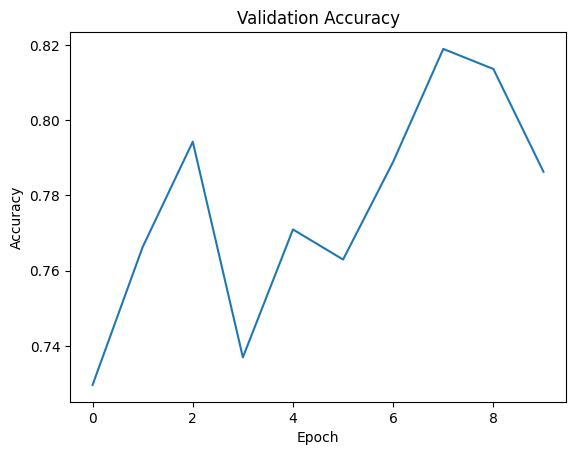

In [31]:
plt.plot(val_accuracies)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

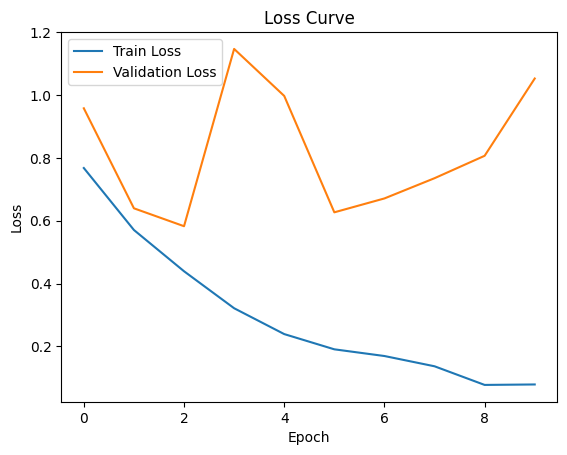

In [32]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.show()

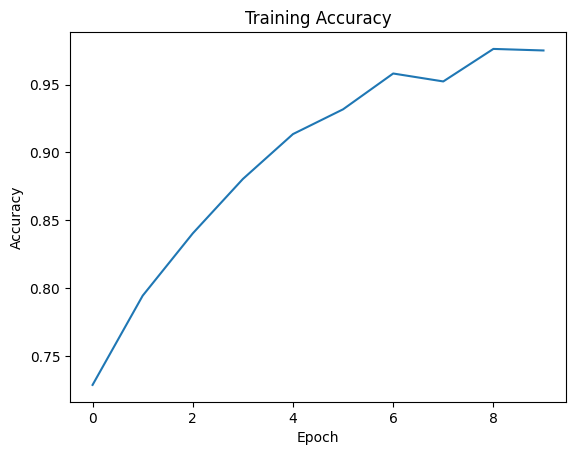

In [33]:
plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.savefig("training_accuracy.png")

plt.show()

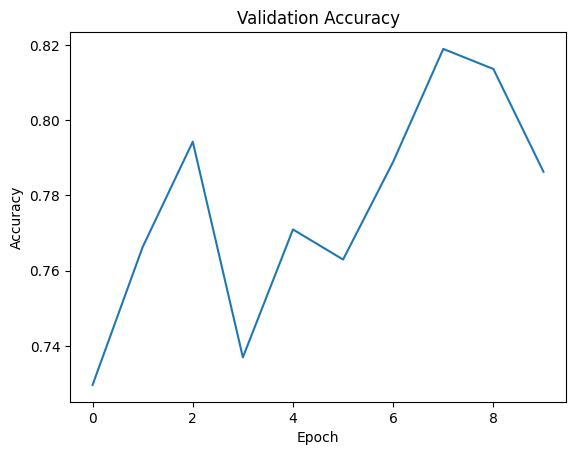

In [34]:
plt.plot(val_accuracies)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.savefig("validation_accuracy.png")

plt.show()

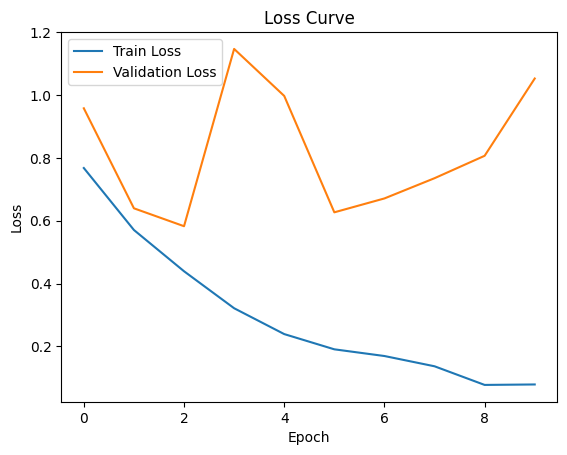

In [35]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.savefig("loss_curve.png")

plt.show()

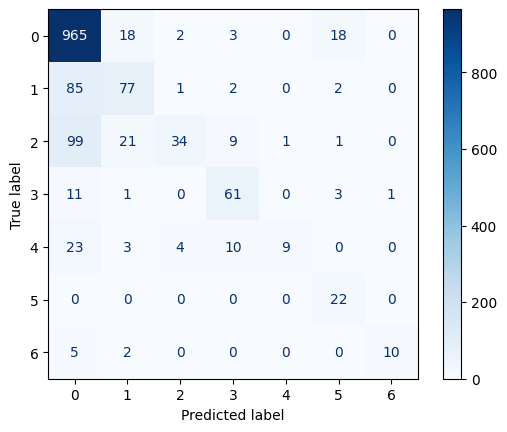

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.savefig("confusion_matrix.png")

plt.show()

In [37]:
import zipfile

with zipfile.ZipFile("senet_model.zip", "w") as zipf:
    zipf.write("senet_skin_model.pth")